# Laboratory #4: Adversarial Learning and OOD Detection

In this laboratory session we will develop a methodology for detecting OOD samples and measuring the quality of OOD detection. We will also experiment with incorporating adversarial examples during training to render models more robust to adversarial attacks.

---
## Exercise 1: OOD Detection and Performance Evaluation
In this first exercise you will build a simple OOD detection pipeline and implement some performance metrics to evaluate its performance.

### Exercise 1.1: Build a simple OOD detection pipeline

Implement an OOD detection pipeline (like in the Flipped Activity notebook) using an ID and an OOD dataset of your choice. Some options:

+ CIFAR-10 (ID), Subset of CIFAR-100 (OOD). You will need to wrap CIFAR-100 in some way to select a subset of classes that are *not* in CIFAR-10 (see `torch.utils.data.Subset`).
+ Labeled Faces in the Wild (ID), CIFAR-10 or FakeData (OOD). The LfW dataset is available in Scikit-learn (see `sklearn.datasets.fetch_lfw_people`).
+ Something else, but if using images keep the images reasonably small!

In this exercise your *OOD Detector* should produce a score representing how "out of distribution" a test sample is. We will implement some metrics in the next exercise, but for now use the techniques from the flipped activity notebook to judge how well OOD scoring is working (i.e. histograms).

**Note**: Make sure you make a validation split of your ID dataset for testing.

In [1]:
# Your code here.

import torch
from torchvision import datasets, transforms
from torch.utils.data import Subset, random_split
import matplotlib.pyplot as plt
import library
from library import train_loop, eval_loop, test_loop, get_msp_scores, generate_adversarial, JARN_train_loop

# Set if models should be trained or loaded
load = True

train_transform = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.247, 0.243, 0.261)), 
])

test_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.247, 0.243, 0.261)),
])

cifar10_train_split = datasets.CIFAR10(root='./_data', train=True, download=True, transform=train_transform)
cifar10_test = datasets.CIFAR10(root='./_data', train=False, download=True, transform=test_transform)

# Create subsets for training and validation
generator = torch.Generator().manual_seed(42)
train_size = int(0.8 * len(cifar10_train_split))
val_size = len(cifar10_train_split) - train_size
cifar10_train, cifar10_val = random_split(cifar10_train_split, [train_size, val_size], generator=generator)

cifar100_test = datasets.CIFAR100(root='./_data', train=False, download=True, transform=test_transform)

for i,c in enumerate(cifar100_test.classes):
    print(i, c)


0 apple
1 aquarium_fish
2 baby
3 bear
4 beaver
5 bed
6 bee
7 beetle
8 bicycle
9 bottle
10 bowl
11 boy
12 bridge
13 bus
14 butterfly
15 camel
16 can
17 castle
18 caterpillar
19 cattle
20 chair
21 chimpanzee
22 clock
23 cloud
24 cockroach
25 couch
26 crab
27 crocodile
28 cup
29 dinosaur
30 dolphin
31 elephant
32 flatfish
33 forest
34 fox
35 girl
36 hamster
37 house
38 kangaroo
39 keyboard
40 lamp
41 lawn_mower
42 leopard
43 lion
44 lizard
45 lobster
46 man
47 maple_tree
48 motorcycle
49 mountain
50 mouse
51 mushroom
52 oak_tree
53 orange
54 orchid
55 otter
56 palm_tree
57 pear
58 pickup_truck
59 pine_tree
60 plain
61 plate
62 poppy
63 porcupine
64 possum
65 rabbit
66 raccoon
67 ray
68 road
69 rocket
70 rose
71 sea
72 seal
73 shark
74 shrew
75 skunk
76 skyscraper
77 snail
78 snake
79 spider
80 squirrel
81 streetcar
82 sunflower
83 sweet_pepper
84 table
85 tank
86 telephone
87 television
88 tiger
89 tractor
90 train
91 trout
92 tulip
93 turtle
94 wardrobe
95 whale
96 willow_tree
97 wolf
98

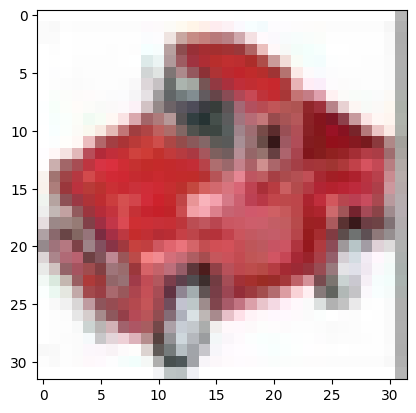

In [2]:
# The only class overlapping seems to be truck (CIFAR10) and pickup truck (CIFAR100).
overlapping_class = 58

# Take first image to confirm it's a truck.
truck_img = cifar100_test.data[cifar100_test.targets.index(overlapping_class)]
plt.imshow(truck_img)
plt.show()

In [3]:
ood_indices = [i for i, label in enumerate(cifar100_test.targets) if label != overlapping_class]
cifar100_ood = Subset(cifar100_test, ood_indices)
print(f"CIFAR100 OOD dataset size: {len(cifar100_ood)}")

CIFAR100 OOD dataset size: 9900


Now we have our ID dataset (cifar10) which will be used to train a ResNet-18 and the OOD dataset (cifar100 without pickup trucks). We can start creating our dataloader for training and testing the ResNet-18 

In [4]:
from torch.utils.data import DataLoader
from torchvision import models

train_loader = DataLoader(cifar10_train, batch_size=64, shuffle=True)
val_loader = DataLoader(cifar10_val, batch_size=64, shuffle=False)
test_loader = DataLoader(cifar10_test, batch_size=64, shuffle=False)
ood_loader = DataLoader(cifar100_ood, batch_size=64, shuffle=False)

resnet18 = models.resnet18(weights=None)
print(resnet18.fc)

Linear(in_features=512, out_features=1000, bias=True)


The final fully connected layer of the ResNet has 1000 out_features while cifar10 has 10 classes

In [5]:
resnet18.fc = torch.nn.Linear(resnet18.fc.in_features, 10)
print(resnet18.fc)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')


Linear(in_features=512, out_features=10, bias=True)


In [6]:
# TRAIN OR LOAD CELL
resnet18.to(device)

params_dict = {
    'optimizer': torch.optim.AdamW(resnet18.parameters(), lr=0.001, weight_decay=0.01),
    'criterion': torch.nn.CrossEntropyLoss(),
    'device': device
}

best_val_acc = 0.0

if load:
    resnet18.load_state_dict(torch.load('models/best_resnet18_cifar10.pth', map_location=device))

else:
    for epoch in range(10):
        print(f"Epoch {epoch+1}/10")
        epoch_loss, epoch_acc = train_loop(resnet18, train_loader, **params_dict)
        print(f"Training Loss: {epoch_loss:.4f}, Training Accuracy: {epoch_acc:.4f}")

        val_loss, val_acc = eval_loop(resnet18, val_loader, params_dict['criterion'], params_dict['device'])
        print(f"Validation Loss: {val_loss:.4f}, Validation Accuracy: {val_acc:.4f}")

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            torch.save(resnet18.state_dict(), 'models/best_resnet18_cifar10.pth')

Alrternatively, we can also directly load a trained model

In [7]:
loaded_resnet20 = torch.hub.load("chenyaofo/pytorch-cifar-models", "cifar10_resnet20", pretrained=True)
loaded_resnet20.to(device)
loaded_resnet20.eval()

Using cache found in /home/stefano/.cache/torch/hub/chenyaofo_pytorch-cifar-models_master


CifarResNet(
  (conv1): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
  (bn1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(16, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(16, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(16, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(16, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias

Let's see the performance on test set of the two nets.

In [8]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

result18 = test_loop(resnet18, val_loader, device)
result20 = test_loop(loaded_resnet20, test_loader, device)

print(classification_report(result18['labels'], result18['predictions']))
print(classification_report(result20['labels'], result20['predictions']))

              precision    recall  f1-score   support

           0       0.79      0.77      0.78       973
           1       0.83      0.87      0.85      1010
           2       0.73      0.69      0.71      1006
           3       0.54      0.63      0.58       967
           4       0.69      0.75      0.72       963
           5       0.81      0.46      0.59      1024
           6       0.77      0.84      0.80      1025
           7       0.75      0.83      0.79      1035
           8       0.81      0.87      0.84       998
           9       0.84      0.79      0.82       999

    accuracy                           0.75     10000
   macro avg       0.76      0.75      0.75     10000
weighted avg       0.76      0.75      0.75     10000

              precision    recall  f1-score   support

           0       0.92      0.93      0.92      1000
           1       0.96      0.97      0.96      1000
           2       0.89      0.91      0.90      1000
           3       0.84 

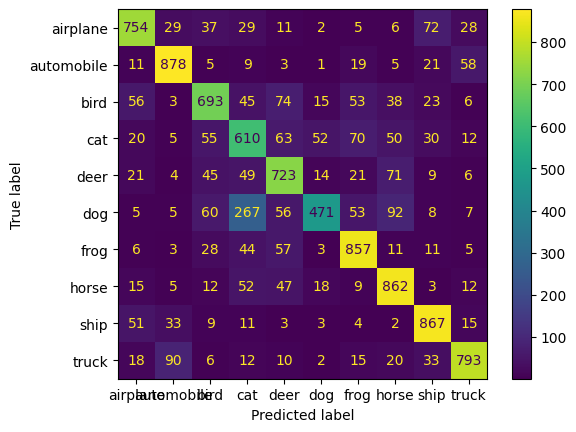

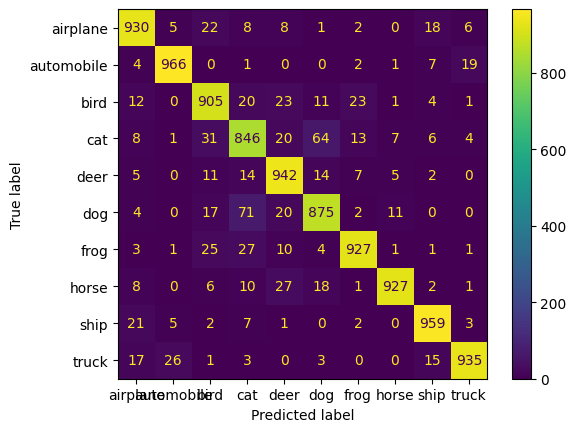

In [9]:
cm18 = confusion_matrix(result18['labels'], result18['predictions'])
cm20 = confusion_matrix(result20['labels'], result20['predictions'])

display18 = ConfusionMatrixDisplay(confusion_matrix=cm18, display_labels=cifar10_train_split.classes)
display20 = ConfusionMatrixDisplay(confusion_matrix=cm20, display_labels=cifar10_train_split.classes)

display18.plot()
display20.plot()
plt.show()

Pretrained ResNet20 is has very better performance compared to our ResNet18

Now we have to use outputs from the model to create an OOD detector. The baseline idea could be taking the Maximum Softmax Probabilities. Theoretically, the model should be more confident (higher MSP scores) on the ID images rather than the OOD ones.

In [10]:

def plot_histograms(id_scores, ood_scores):
    plt.figure(figsize=(8, 5))

    plt.hist(id_scores, bins=50, alpha=0.6, density=True, label='In-Distribution (CIFAR-10)')
    plt.hist(ood_scores, bins=50, alpha=0.6, density=True, label='Out-of-Distribution (CIFAR-100)')

    plt.title('MSP scores distribution')
    plt.xlabel('Maximum Softmax Probability (Confidence)')
    plt.ylabel('Density')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

Histograms for our ResNet18

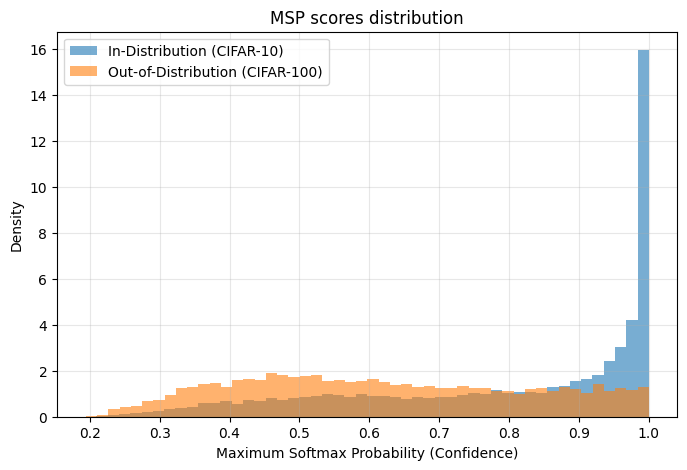

In [11]:
id_scores = get_msp_scores(resnet18, test_loader, device)
ood_scores = get_msp_scores(resnet18, ood_loader, device)
plot_histograms(id_scores, ood_scores)

Histograms for the loaded ResNet20

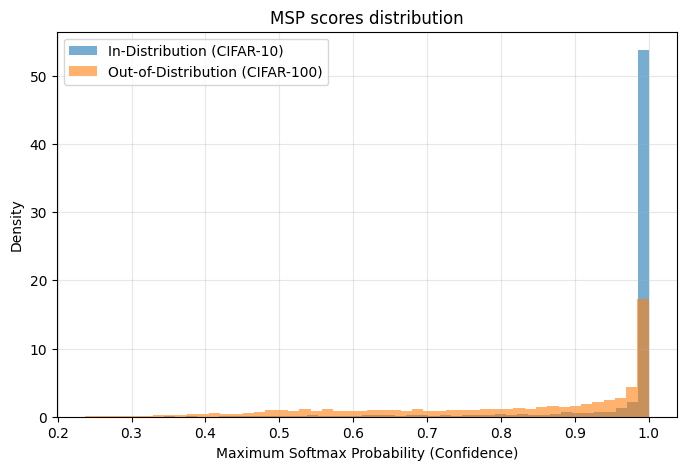

In [12]:
id_scores_loaded = get_msp_scores(loaded_resnet20, test_loader, device)
ood_scores_loaded = get_msp_scores(loaded_resnet20, ood_loader, device)
plot_histograms(id_scores_loaded, ood_scores_loaded)

We can see that OOD samples tend to have lower MSP scores but many of them have MSP score close to 1.0.

In addition, we can say that the ResNet20 is way more confident about the In-Distribution instances. This will probably lead to a better OOD detection performance

### Exercise 1.2: Measure your OOD detection performance

There are several metrics used to evaluate OOD detection performance, we will concentrate on two threshold-free approaches: the area under the Receiver Operator Characteristic (ROC) curve for ID classification, and the area under the Precision-Recall curve for *both* ID and OOD scoring. See [the ODIN paper](https://arxiv.org/pdf/1706.02690.pdf) section 4.3 for a description of OOD metrics.

Use the functions in `sklearn.metrics` to produce ROC and PR curves for your OOD detector. Some useful functions:

+ [`sklearn.metric.RocCurveDisplay.from_predictions`](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.RocCurveDisplay.html)
+ [`sklearn.metrics.PrecisionRecallDisplay`](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.PrecisionRecallDisplay.html)


In [13]:
# Your code here.
import numpy as np
from sklearn.metrics import RocCurveDisplay, PrecisionRecallDisplay


def plot_roc_pr_curves(id_scores, ood_scores):
    y_pred = np.concatenate([id_scores, ood_scores])
    y_real = np.ones(len(id_scores))
    y_fake = np.zeros(len(ood_scores))

    y_true = np.concatenate([y_real, y_fake])

    RocCurveDisplay.from_predictions(y_true, y_pred)
    PrecisionRecallDisplay.from_predictions(y_true, y_pred)

ROC and PR curves for our trained ResNet18

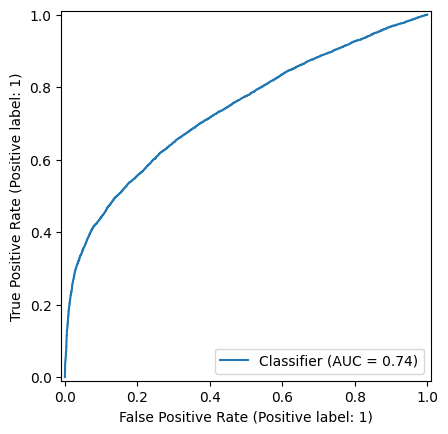

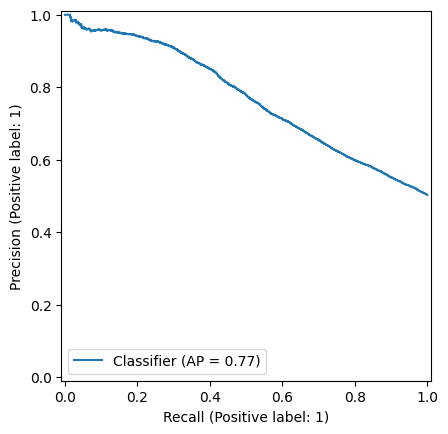

In [14]:
plot_roc_pr_curves(id_scores, ood_scores)

ROC and PR curves for the loaded ResNet20

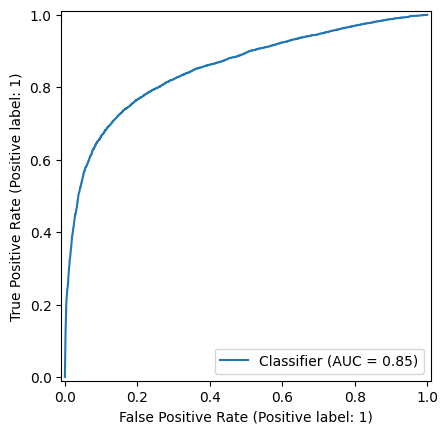

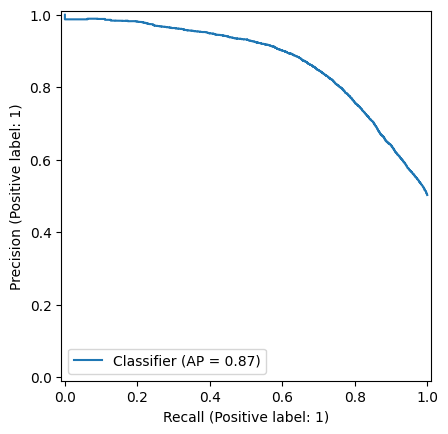

In [15]:
plot_roc_pr_curves(id_scores_loaded, ood_scores_loaded)

The pretrained ResNet20 performs better than our badly trained ResNet18 

### Use of AI

Used gemini 3.1 Pro: https://gemini.google.com/share/10d557b385e9

---
## Exercise 2: Enhancing Robustness to Adversarial Attack

In this second exercise we will experiment with enhancing our base model to be (more) robust to adversarial attacks. 

### Exercise 2.1: Implement FGSM and generate adversarial examples

Recall that the Fast Gradient Sign Method (FGSM) perturbs samples in the direction of the gradient with respect to the input $\mathbf{x}$:
$$ \boldsymbol{\eta}(\mathbf{x}) = \varepsilon \mathrm{sign}(\nabla_{\mathbf{x}} \mathcal{L}(\boldsymbol{\theta}, \mathbf{x}, y)) ) $$
Implement FGSM and generate some *adversarial examples* using your trained ID model. Evaluate these samples qualitatively and quantitatively. Evaluate how dependent on $\varepsilon$ the quality of these samples are. 

In [16]:
cifar10_class_dict = {cls : i for i, cls in enumerate(cifar10_train_split.classes)}
cifar10_class_dict = {**cifar10_class_dict, "none": None}

print(cifar10_class_dict)

{'airplane': 0, 'automobile': 1, 'bird': 2, 'cat': 3, 'deer': 4, 'dog': 5, 'frog': 6, 'horse': 7, 'ship': 8, 'truck': 9, 'none': None}


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.9894737..1.4716679].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.9894737..1.5983055].


Generated 46 adversarial examples from the first batch of validation data.
Success rate: 0.96 (44/46)
Target class: cat
Target Success Rate: 0.41


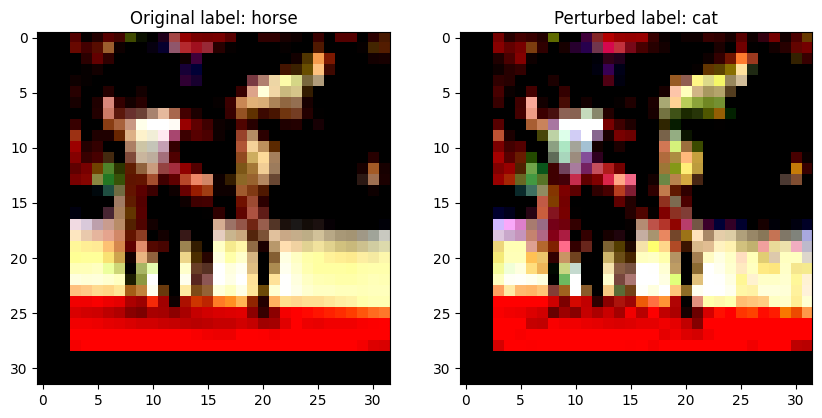

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.9894737..1.5337529].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.9894737..1.4046478].


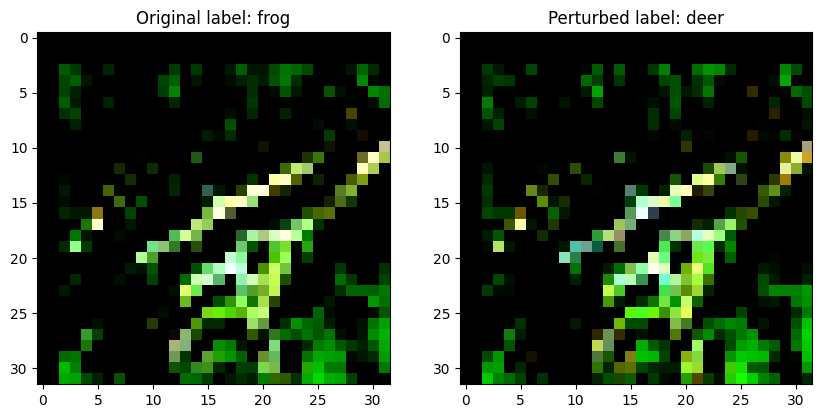

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.9894737..1.2652695].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.9894737..1.3400953].


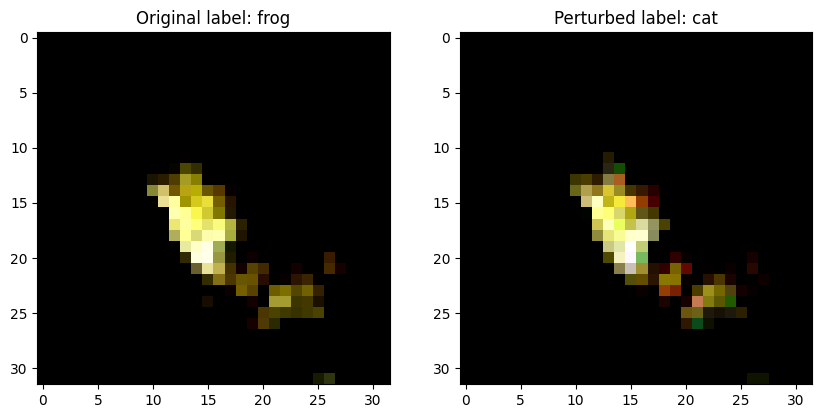

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.9894737..2.1308641].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.9894737..2.1308641].


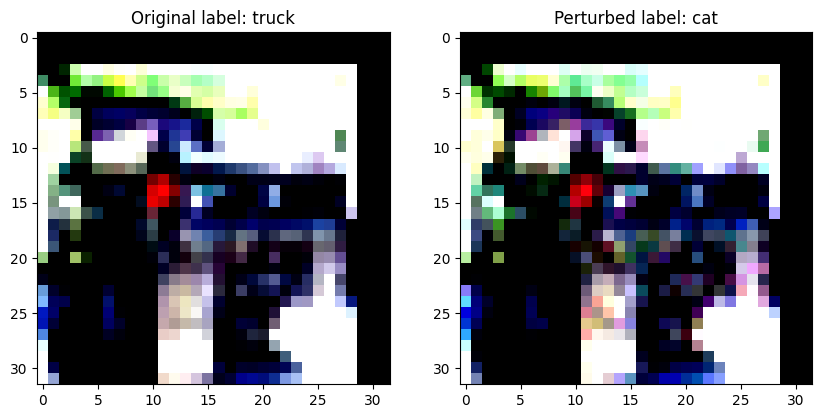

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.9894737..1.8802869].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.9894737..2.0004883].


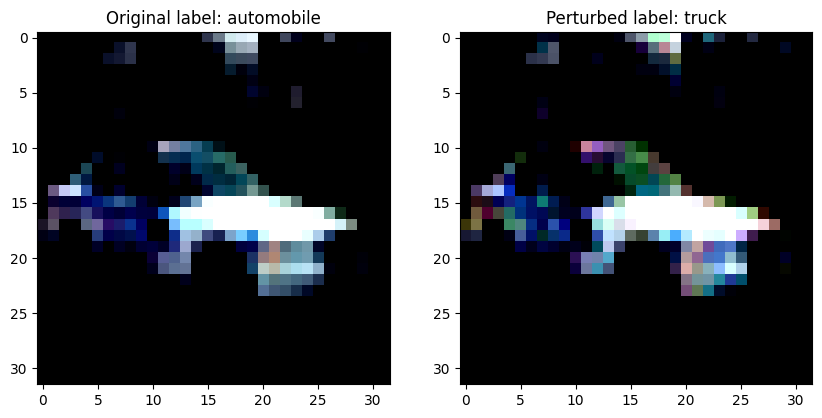

In [17]:
attack_params_dict = {
    'eps': 8/255,
    'target_class': cifar10_class_dict['cat'],
    'num_iterations': 1
}
  
for images, labels in val_loader:

    images, labels = images.to(device), labels.to(device)

    with torch.no_grad():
        outputs = resnet18(images)
        correct_preds = (outputs.argmax(dim=1) == labels).cpu().numpy()

    images = images[correct_preds]  ##### NOTE: check this
    labels = labels[correct_preds]

    if attack_params_dict['target_class'] is not None:
        # For targeted attacks, we only want to attack samples that are NOT already in the target class
        mask = (labels != attack_params_dict['target_class'])
        images = images[mask]
        labels = labels[mask]


    adv_images = generate_adversarial(
        model=resnet18, 
        criterion=params_dict['criterion'], 
        images=images, 
        labels=labels, 
        eps=attack_params_dict['eps'], 
        target_class=attack_params_dict['target_class'], 
        num_iterations=attack_params_dict['num_iterations'],
        device=device
    )

    with torch.no_grad():
        adv_outputs = resnet18(adv_images)
        adv_preds = adv_outputs.argmax(dim=1)

    perturbed_tuples = [(images[i], adv_images[i], labels[i].cpu(), adv_preds[i].cpu()) for i in range(len(adv_images))]
    break

print(f"Generated {len(perturbed_tuples)} adversarial examples from the first batch of validation data.")

successful_attacks = sum(1 for t in perturbed_tuples if t[2] != t[3])
print(f"Success rate: {successful_attacks/len(perturbed_tuples):.2f} ({successful_attacks}/{len(perturbed_tuples)})")

if attack_params_dict['target_class'] is not None:
    print(f"Target class: {cifar10_train_split.classes[attack_params_dict['target_class']]}")
    print(f"Target Success Rate: {sum(1 for t in perturbed_tuples if t[3] == attack_params_dict['target_class'])/len(perturbed_tuples):.2f}")

# Take only the successful attacks for visualization.
perturbed_tuples = [t for t in perturbed_tuples if t[2] != t[3]]
perturbed_tuples = perturbed_tuples[:min(5, len(perturbed_tuples))]

for perturbed_tuple in perturbed_tuples:
    fig, axes = plt.subplots(1, 2, figsize=(10, 5))
    axes[0].imshow(perturbed_tuple[0].cpu().detach().permute(1, 2, 0))
    axes[1].imshow(perturbed_tuple[1].cpu().detach().permute(1, 2, 0))
    axes[0].set_title(f"Original label: {cifar10_train_split.classes[perturbed_tuple[2].item()]}")
    axes[1].set_title(f"Perturbed label: {cifar10_train_split.classes[perturbed_tuple[3].item()]}")
    plt.show()

### Exercise 2.2: Augment training with adversarial examples

Use your implementation of FGSM to augment your training dataset with adversarial samples. Ideally, you should implement this data augmentation *on the fly* so that the adversarial samples are always generated using the current model. Evaluate whether the model is more (or less) robust to ID samples using your OOD detection pipeline and metrics you implemented in Exercise 1.

In [18]:
# TRAIN OR LOAD CELL

adv_resnet18 = models.resnet18(weights=None)
adv_resnet18.fc = torch.nn.Linear(adv_resnet18.fc.in_features, 10)
adv_resnet18.to(device)

adv_params_dict = {
    'optimizer': torch.optim.AdamW(adv_resnet18.parameters(), lr=0.001, weight_decay=0.01),
    'criterion': torch.nn.CrossEntropyLoss(),
    'device': device
}

if load:
    adv_resnet18.load_state_dict(torch.load('models/best_adv_resnet18_cifar10.pth', map_location=device))

else:
    best_val_acc = 0.0
    for epoch in range(10):
        print(f"Epoch {epoch+1}/10")
        epoch_loss, epoch_acc = train_loop(adv_resnet18, train_loader, **adv_params_dict, adv = True, attack_params_dict=attack_params_dict)
        print(f"Training Loss: {epoch_loss:.4f}, Training Accuracy: {epoch_acc:.4f}")

        val_loss, val_acc = eval_loop(adv_resnet18, val_loader, adv_params_dict['criterion'], adv_params_dict['device'], adv=True, attack_params_dict=attack_params_dict)
        print(f"Validation Loss: {val_loss:.4f}, Validation Accuracy: {val_acc:.4f}")

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            torch.save(adv_resnet18.state_dict(), 'models/best_adv_resnet18_cifar10.pth')

First of all, let's compare the accuracy on the test set of the original ResNet18 and the one trained with adversarial examples. 

### Classification report of the original ResNet18 on original test set

In [19]:
result = test_loop(resnet18, test_loader, device) 
print(classification_report(result['labels'], result['predictions']))


              precision    recall  f1-score   support

           0       0.76      0.80      0.78      1000
           1       0.86      0.90      0.88      1000
           2       0.74      0.69      0.72      1000
           3       0.58      0.66      0.61      1000
           4       0.74      0.78      0.76      1000
           5       0.81      0.49      0.61      1000
           6       0.77      0.86      0.81      1000
           7       0.79      0.83      0.81      1000
           8       0.80      0.87      0.84      1000
           9       0.88      0.81      0.84      1000

    accuracy                           0.77     10000
   macro avg       0.77      0.77      0.77     10000
weighted avg       0.77      0.77      0.77     10000



### Classification report of the adversarially trained ResNet18 on original test set

In [20]:
adv_result = test_loop(adv_resnet18, test_loader, device)
print(classification_report(adv_result['labels'], adv_result['predictions']))

              precision    recall  f1-score   support

           0       0.74      0.80      0.77      1000
           1       0.85      0.84      0.85      1000
           2       0.61      0.68      0.64      1000
           3       0.76      0.17      0.28      1000
           4       0.66      0.68      0.67      1000
           5       0.62      0.68      0.65      1000
           6       0.67      0.86      0.75      1000
           7       0.80      0.79      0.79      1000
           8       0.83      0.88      0.86      1000
           9       0.77      0.87      0.82      1000

    accuracy                           0.73     10000
   macro avg       0.73      0.73      0.71     10000
weighted avg       0.73      0.73      0.71     10000



### Confusion matrix of the original ResNet18 on original test set

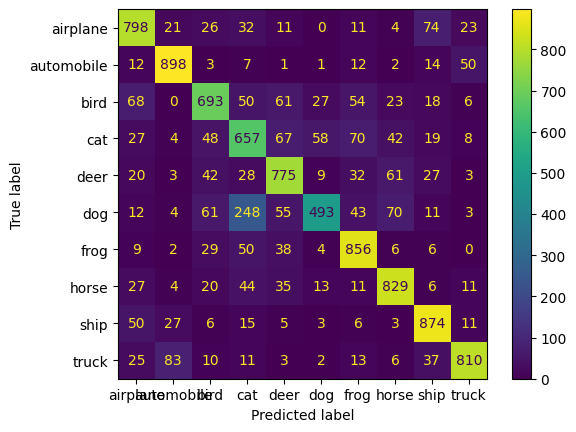

In [21]:
cm = confusion_matrix(result['labels'], result['predictions'])

display = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=cifar10_train_split.classes)
display.plot()

plt.show()

### Confusion matrix of the adversarially trained ResNet18 on original test set

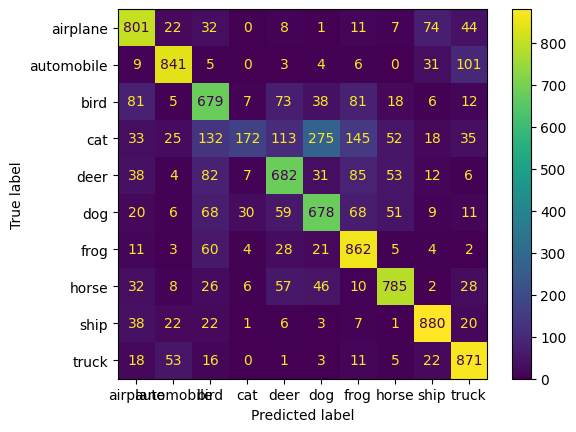

In [22]:
adv_cm = confusion_matrix(adv_result['labels'], adv_result['predictions'])
adv_display = ConfusionMatrixDisplay(confusion_matrix=adv_cm, display_labels=cifar10_train_split.classes)
adv_display.plot()
plt.show()

It is curious to see that the net trained with adversarial perturbed examples has overall similar performance compared to the original, except that for 'cat' class which was the target of our attack.

But what happens if in the test set we have only adversarial perturbed images?

### Classification report of the original ResNet18 on 'cat' perturbed test set

In [23]:
result = test_loop(resnet18, test_loader, device, adv = True, criterion=adv_params_dict['criterion'], attack_params_dict=attack_params_dict) 
print(classification_report(result['labels'], result['predictions']))

              precision    recall  f1-score   support

           0       0.36      0.40      0.38      1000
           1       0.46      0.09      0.15      1000
           2       0.13      0.08      0.10      1000
           3       0.21      0.94      0.34      1000
           4       0.07      0.06      0.06      1000
           5       0.14      0.05      0.07      1000
           6       0.12      0.14      0.13      1000
           7       0.20      0.10      0.14      1000
           8       0.50      0.09      0.15      1000
           9       0.29      0.16      0.21      1000

    accuracy                           0.21     10000
   macro avg       0.25      0.21      0.17     10000
weighted avg       0.25      0.21      0.17     10000



### Classification report of the adversarially trained ResNet18 on 'cat' perturbed test set

In [24]:
adv_result = test_loop(adv_resnet18, test_loader, device, adv = True, criterion=adv_params_dict['criterion'], attack_params_dict=attack_params_dict)
print(classification_report(adv_result['labels'], adv_result['predictions']))

              precision    recall  f1-score   support

           0       0.65      0.60      0.62      1000
           1       0.84      0.58      0.69      1000
           2       0.42      0.36      0.39      1000
           3       0.46      0.59      0.52      1000
           4       0.43      0.41      0.42      1000
           5       0.36      0.55      0.43      1000
           6       0.53      0.49      0.51      1000
           7       0.66      0.52      0.58      1000
           8       0.61      0.69      0.65      1000
           9       0.71      0.62      0.66      1000

    accuracy                           0.54     10000
   macro avg       0.57      0.54      0.55     10000
weighted avg       0.57      0.54      0.55     10000



### Confusion matrix of the original ResNet18 on 'cat' perturbed test set

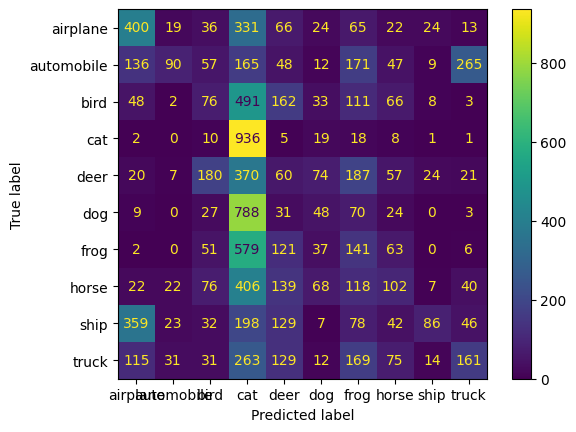

In [25]:
cm = confusion_matrix(result['labels'], result['predictions'])
display = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=cifar10_train_split.classes)

display.plot()
plt.show()

### Confusion matrix of the adversarially trained ResNet18 on 'cat' perturbed test set

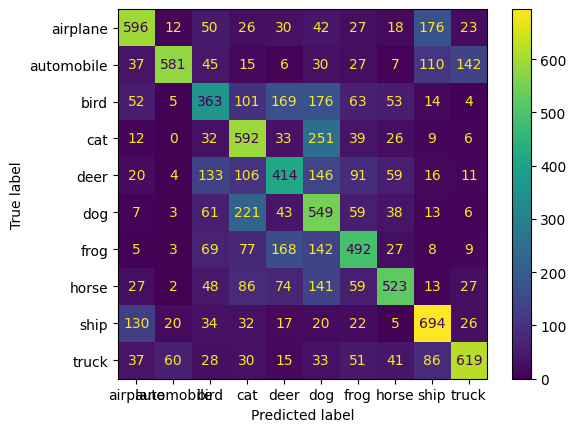

In [26]:
adv_cm = confusion_matrix(adv_result['labels'], adv_result['predictions'])
adv_display = ConfusionMatrixDisplay(confusion_matrix=adv_cm, display_labels=cifar10_train_split.classes)
adv_display.plot()
plt.show()

We can see that the adversarial training allowed an increase in robustness against adversarial attacks. The original model is much more fooled by the targeted attack on 'cat' class. Further study could be done to see output differences for different parameters of adversarial attacks (eps, num_iterations_, target_class)  

Let's now see what impact had adversarial training in OOD detection

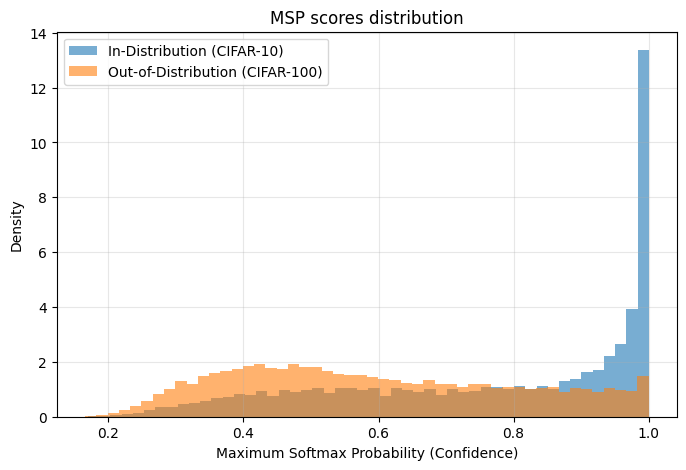

In [27]:
id_scores = get_msp_scores(adv_resnet18, test_loader, device)
ood_scores = get_msp_scores(adv_resnet18, ood_loader, device)
plot_histograms(id_scores, ood_scores)

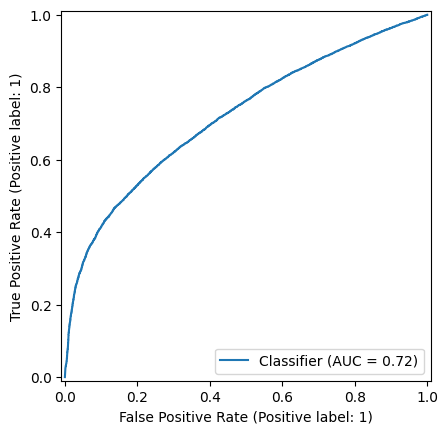

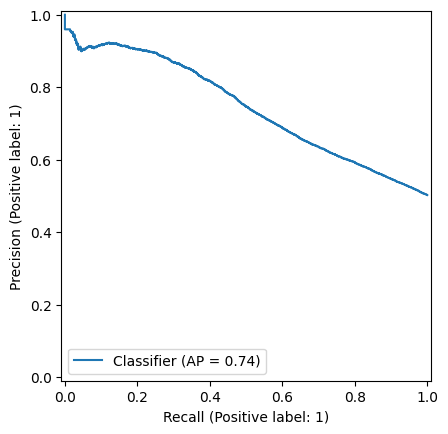

In [28]:
plot_roc_pr_curves(id_scores, ood_scores)

The adversarially trained ResNet18 is a worse OOD detector compared to the original ResNet18

### Use of AI

Used Gemini 3.1 Pro: https://gemini.google.com/share/c00689f911db

---
### Exercise 3.2: Implement JARN
In exercise 2.2 you already implemented Jacobian-regularized learning to make your model more robust to adversarial samples. Add a *discriminator* to your model to encourage the adversarial samples used for regularization to be more *salient*.

See [the JARN paper](https://arxiv.org/abs/1912.10185) for more details.

In [31]:
from importlib import reload

reload(library)

<module 'library' from '/home/stefano/Scrivania/workspace/DLA2026/adversarial_lab/library.py'>

In [33]:
from torch import nn
import torch.nn.functional as F

class Adaptor(nn.Module):
    def __init__(self):
        super().__init__()
        self.bn = nn.BatchNorm2d(3, affine=False)
        self.conv = nn.Conv2d(3,3, kernel_size=1) # convolutional layer with 1x1 filter

    def forward(self, x):
        x = self.bn(x)
        x = self.conv(x)
        return x
    
class Discriminator(nn.Module):

    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(3,32, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(32,64, kernel_size=3, padding=1)
        self.conv3 = nn.Conv2d(64,128, kernel_size=3, padding=1)
        self.conv4 = nn.Conv2d(128,256, kernel_size=3, stride=2, padding=1)
        self.conv5 = nn.Conv2d(256,512, kernel_size=3, stride=2, padding=1)
        
        self.flatten_dim = 512 * 8 * 8  # if we start with x=32x32 
        self.fc1 = nn.Linear(self.flatten_dim, 256)
        self.fc2 = nn.Linear(256,128)
        self.fc3 = nn.Linear(128,1)

    def forward(self, x):
        x = F.relu(self.conv1(x))
        x = F.relu(self.conv2(x))
        x = F.relu(self.conv3(x))
        x = F.relu(self.conv4(x))
        x = F.relu(self.conv5(x))  # 8x8x512

        x = torch.flatten(x,1)

        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.fc3(x) # sigmoid for BCE will be performed using nn.BCEWithLogitsLoss() for better numerical stability

        return x


jarn_resnet18 = models.resnet18(weights=None)
jarn_resnet18.fc = nn.Linear(jarn_resnet18.fc.in_features, 10)
jarn_resnet18.to(device)

adaptor = Adaptor()
adaptor.to(device)
discriminator = Discriminator()
discriminator.to(device)

num_epochs = 20
best_val_acc = 0.0


alpha, beta , gamma = 10e-5, 10e-5, 10e-5

model_optimizer = torch.optim.AdamW(jarn_resnet18.parameters(), lr=alpha, weight_decay=0.001)
adaptor_optimizer = torch.optim.Adam(adaptor.parameters(), lr=beta)
discriminator_optimizer = torch.optim.Adam(discriminator.parameters(), lr=gamma)

load = False
if load:
    jarn_resnet18.load_state_dict(torch.load('models/best_jarn_resnet18_cifar10.pth', map_location = device))
else:
    for epoch in range(num_epochs):

        if epoch >= num_epochs * 0.75:
            print(f"Epoch {epoch+1}/{num_epochs} JARN")
            g_loss, adv_loss, acc = library.JARN_train_loop(jarn_resnet18, adaptor, discriminator, model_optimizer, adaptor_optimizer, discriminator_optimizer, train_loader, device, 8/255)
            print(f"Generator Loss:{g_loss:.4f}, Adv Loss: {adv_loss:.4f}, Accuracy: {acc:.4f}")
        else:
            print(f"Epoch {epoch+1}/{num_epochs} STANDARD")
            epoch_loss, epoch_acc = train_loop(jarn_resnet18, train_loader, **adv_params_dict, adv = False)
            print(f"Training Loss: {epoch_loss:.4f}, Training Accuracy: {epoch_acc:.4f}")

        val_loss, val_acc = eval_loop(jarn_resnet18, val_loader, adv_params_dict['criterion'], adv_params_dict['device'], adv=True, attack_params_dict=attack_params_dict)
        print(f"Validation Loss: {val_loss:.4f},  Validation Accuracy: {val_acc:.4f}")

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            torch.save(jarn_resnet18.state_dict(), 'models/best_jarn_resnet18_cifar10.pth') 

Epoch 1/20 STANDARD
Training Loss: 2.5079, Training Accuracy: 0.1086
Validation Loss: 2.5182,  Validation Accuracy: 0.1063
Epoch 2/20 STANDARD
Training Loss: 2.5104, Training Accuracy: 0.1087
Validation Loss: 2.5174,  Validation Accuracy: 0.1106
Epoch 3/20 STANDARD
Training Loss: 2.5107, Training Accuracy: 0.1079
Validation Loss: 2.5075,  Validation Accuracy: 0.1089
Epoch 4/20 STANDARD
Training Loss: 2.5110, Training Accuracy: 0.1072
Validation Loss: 2.5123,  Validation Accuracy: 0.1114
Epoch 5/20 STANDARD
Training Loss: 2.5089, Training Accuracy: 0.1091
Validation Loss: 2.5176,  Validation Accuracy: 0.1062
Epoch 6/20 STANDARD
Training Loss: 2.5104, Training Accuracy: 0.1081
Validation Loss: 2.5071,  Validation Accuracy: 0.1088
Epoch 7/20 STANDARD
Training Loss: 2.5088, Training Accuracy: 0.1096
Validation Loss: 2.5115,  Validation Accuracy: 0.1102
Epoch 8/20 STANDARD
Training Loss: 2.5090, Training Accuracy: 0.1082
Validation Loss: 2.5152,  Validation Accuracy: 0.1047
Epoch 9/20 STAND

Once we trained our model with JARN technique, we can see our results and compare them with the adversarial trained ResNet18

### Results of JARN and the adversarial trained Resnet18 on original test set

In [34]:
jarn_result = test_loop(jarn_resnet18, test_loader, device)
print(classification_report(jarn_result['labels'], jarn_result['predictions']))
adv_result = test_loop(adv_resnet18, test_loader, device)
print(classification_report(adv_result['labels'], adv_result['predictions']))

              precision    recall  f1-score   support

           0       0.27      0.64      0.38      1000
           1       0.61      0.19      0.29      1000
           2       0.19      0.60      0.28      1000
           3       0.33      0.03      0.06      1000
           4       0.28      0.22      0.25      1000
           5       0.35      0.12      0.18      1000
           6       0.48      0.07      0.13      1000
           7       0.32      0.55      0.41      1000
           8       0.49      0.23      0.32      1000
           9       0.52      0.25      0.33      1000

    accuracy                           0.29     10000
   macro avg       0.38      0.29      0.26     10000
weighted avg       0.38      0.29      0.26     10000

              precision    recall  f1-score   support

           0       0.74      0.80      0.77      1000
           1       0.85      0.84      0.85      1000
           2       0.61      0.68      0.64      1000
           3       0.76 

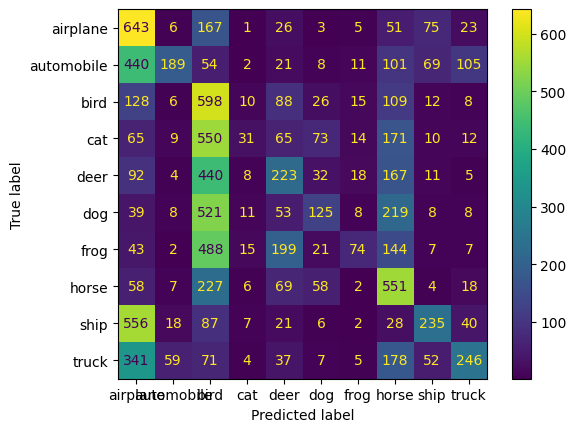

In [35]:
jarn_cm = confusion_matrix(jarn_result['labels'], jarn_result['predictions'])
jarn_display = ConfusionMatrixDisplay(confusion_matrix=jarn_cm, display_labels=cifar10_train_split.classes)
jarn_display.plot()
plt.show()


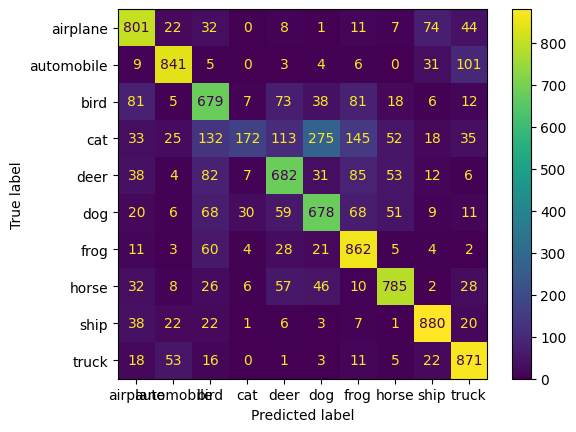

In [36]:
adv_cm = confusion_matrix(adv_result['labels'], adv_result['predictions'])
adv_display = ConfusionMatrixDisplay(confusion_matrix=adv_cm, display_labels=cifar10_train_split.classes)
adv_display.plot()
plt.show()

### Results on 'cat' perturbed test set

In [37]:
jarn_result = test_loop(jarn_resnet18, test_loader, device, adv=True,criterion=adv_params_dict['criterion'], attack_params_dict=attack_params_dict)
print(classification_report(jarn_result['labels'], jarn_result['predictions']))
adv_result = test_loop(adv_resnet18, test_loader, device, adv=True,criterion=adv_params_dict['criterion'], attack_params_dict=attack_params_dict)
print(classification_report(adv_result['labels'], adv_result['predictions']))

              precision    recall  f1-score   support

           0       0.20      0.05      0.08      1000
           1       0.13      0.15      0.14      1000
           2       0.10      0.06      0.07      1000
           3       0.17      0.44      0.25      1000
           4       0.10      0.03      0.05      1000
           5       0.14      0.13      0.14      1000
           6       0.18      0.18      0.18      1000
           7       0.10      0.03      0.05      1000
           8       0.27      0.37      0.31      1000
           9       0.18      0.28      0.22      1000

    accuracy                           0.17     10000
   macro avg       0.16      0.17      0.15     10000
weighted avg       0.16      0.17      0.15     10000

              precision    recall  f1-score   support

           0       0.65      0.60      0.62      1000
           1       0.84      0.58      0.69      1000
           2       0.42      0.36      0.39      1000
           3       0.46 

### Results on untargeted perturbed test set

In [38]:
attack_params_dict = {
    'eps': 8/255,
    'target_class': None,
    'num_iterations': 1
}

jarn_result = test_loop(jarn_resnet18, test_loader, device, adv=True,criterion=adv_params_dict['criterion'], attack_params_dict=attack_params_dict)
print(classification_report(jarn_result['labels'], jarn_result['predictions']))
adv_result = test_loop(adv_resnet18, test_loader, device, adv=True,criterion=adv_params_dict['criterion'], attack_params_dict=attack_params_dict)
print(classification_report(adv_result['labels'], adv_result['predictions']))

              precision    recall  f1-score   support

           0       0.00      0.01      0.01      1000
           1       0.00      0.00      0.00      1000
           2       0.02      0.03      0.02      1000
           3       0.00      0.00      0.00      1000
           4       0.01      0.03      0.01      1000
           5       0.00      0.00      0.00      1000
           6       0.00      0.00      0.00      1000
           7       0.05      0.03      0.04      1000
           8       0.00      0.00      0.00      1000
           9       0.00      0.00      0.00      1000

    accuracy                           0.01     10000
   macro avg       0.01      0.01      0.01     10000
weighted avg       0.01      0.01      0.01     10000

              precision    recall  f1-score   support

           0       0.30      0.33      0.32      1000
           1       0.27      0.23      0.25      1000
           2       0.10      0.14      0.12      1000
           3       0.04 

### It doesn't seem to work...

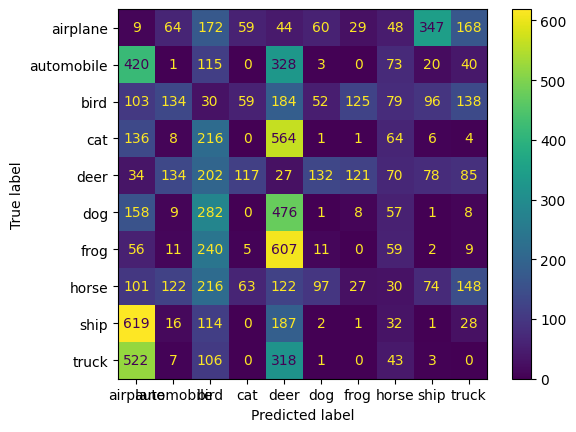

In [39]:
jarn_cm = confusion_matrix(jarn_result['labels'], jarn_result['predictions'])
jarn_display = ConfusionMatrixDisplay(confusion_matrix=jarn_cm, display_labels=cifar10_train_split.classes)
jarn_display.plot()
plt.show()

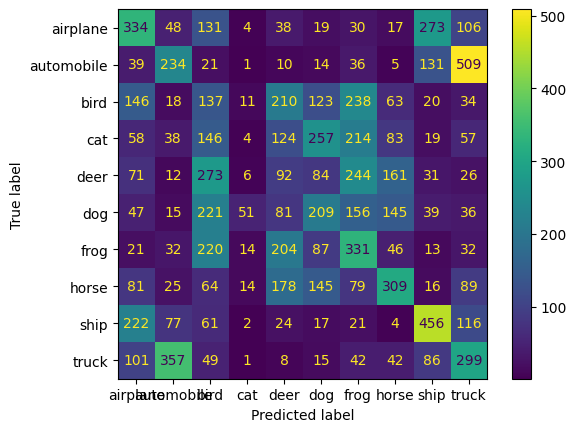

In [40]:
adv_cm = confusion_matrix(adv_result['labels'], adv_result['predictions'])
adv_display = ConfusionMatrixDisplay(confusion_matrix=adv_cm, display_labels=cifar10_train_split.classes)
adv_display.plot()
plt.show()

Used Gemini 3.1 Pro Extended to understand and implement JARN: https://gemini.google.com/share/3fb9a2f5c405